# 5. Problema B: Predicción de default.payment.next.month

### 5.1 Definición y verificación de leakage

Se aborda un problema de **clasificación binaria** cuyo objetivo es predecir si un cliente incumplirá su pago el siguiente mes (1=sí, 0=no).

A diferencia del Problema A, aquí **no existe riesgo de data leakage temporal** porque la variable objetivo `default.payment.next.month` representa un evento futuro respecto a todos los datos disponibles en el dataset. Es decir, todas las variables (abril a septiembre de 2005) son históricas respecto al default, por lo que pueden usarse como features.

Sin embargo, se excluye `PAY_AMT4` como feature ya que fue la variable objetivo del Problema A y podría introducir un sesgo indebido.

**Variables utilizadas:**
- Demográficas: `LIMIT_BAL`, `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`
- Estado de pagos: `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`
- Montos de factura: `BILL_AMT1` a `BILL_AMT6`
- Montos de pago: `PAY_AMT1`, `PAY_AMT2`, `PAY_AMT3`, `PAY_AMT5`, `PAY_AMT6`

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Emiliano\Desktop\BLUEPRUEBA\default_limpio.csv")

features_b = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
              "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
              "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
              "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT5", "PAY_AMT6"]

target_b = "default payment next month"

X_b = df[features_b]
y_b = df[target_b]

print("Features utilizadas:", len(features_b))
print("Shape X:", X_b.shape)
print("Distribución del target:")
print(y_b.value_counts())
print(f"\n% Default: {y_b.mean()*100:.2f}%")

Features utilizadas: 22
Shape X: (30000, 22)
Distribución del target:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

% Default: 22.12%


### 5.2 EDA Específica (default.payment.next.month)

Se analiza la distribución de la variable objetivo y su relación con las features principales.
Se observa un dataset desbalanceado con 22.12% de clientes en default.

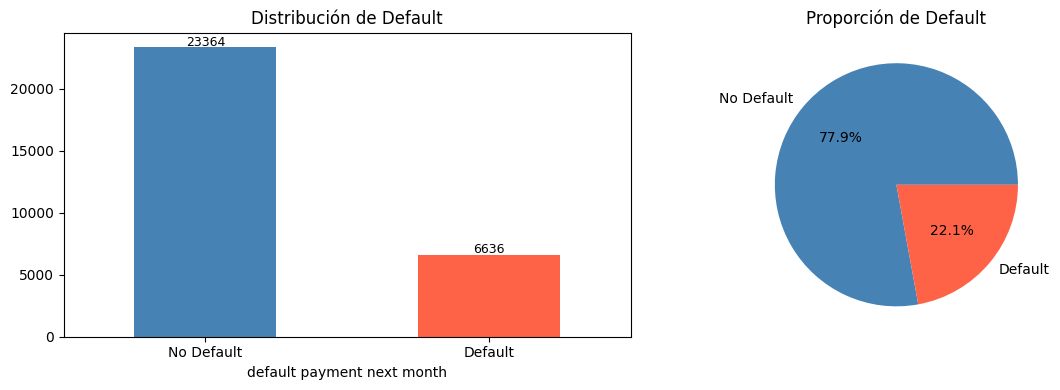

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_b.value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"]) # Conteo.
axes[0].set_title("Distribución de Default")
axes[0].set_xticklabels(["No Default", "Default"], rotation=0)
for i, v in enumerate(y_b.value_counts()):
    axes[0].text(i, v + 100, str(v), ha="center", fontsize=9)

y_b.value_counts(normalize=True).plot(kind="pie", ax=axes[1],
    labels=["No Default", "Default"], autopct="%1.1f%%",
    colors=["steelblue", "tomato"])
axes[1].set_title("Proporción de Default")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

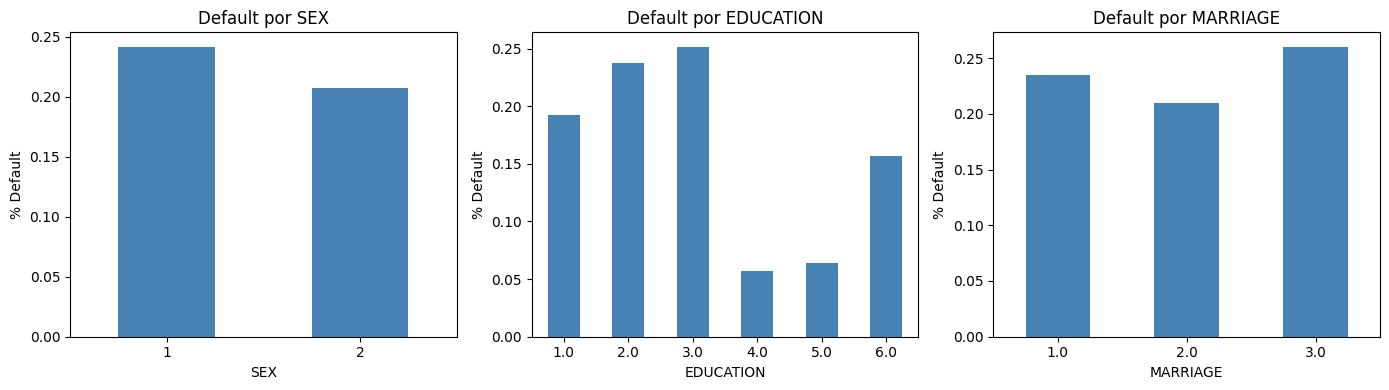

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, titulo in zip(axes,
                            ["SEX", "EDUCATION", "MARRIAGE"],
                            ["Default por SEX", "Default por EDUCATION", "Default por MARRIAGE"]):
    df.groupby(col)[target_b].mean().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(titulo)
    ax.set_ylabel("% Default")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

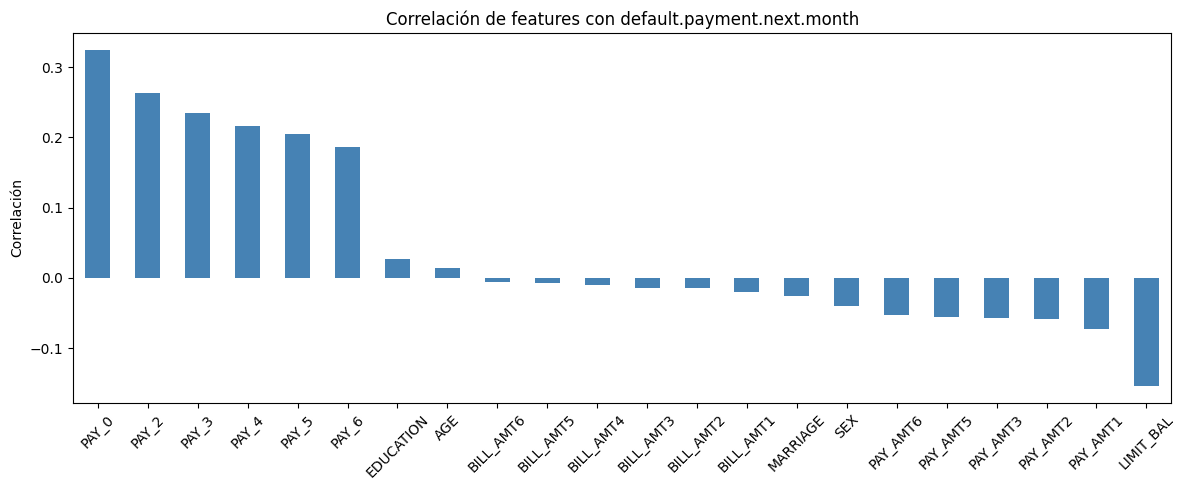

PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.027460
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.026224
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: default payment next month, dtype: float64


In [4]:
correlaciones_b = df[features_b + [target_b]].corr()[target_b].drop(target_b).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
correlaciones_b.plot(kind="bar", color="steelblue")
plt.title("Correlación de features con default.payment.next.month")
plt.ylabel("Correlación")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(correlaciones_b)

### 5.3 Feature Engineering

Garcias a las nuevas variables basadas en el comportamiento de pago del cliente para enriquecer el modelo de clasificación.

In [6]:
import numpy as np

cols_pay_status = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]    # Número de meses con retraso en el pago.
df["MESES_RETRASO"] = (df[cols_pay_status] > 0).sum(axis=1)

df["MAX_RETRASO"] = df[cols_pay_status].max(axis=1)     # Retraso maxiumo registrado.


cols_bill = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]   # Promedio de facturas.
df["BILL_PROM"] = df[cols_bill].mean(axis=1)


cols_pay_amt = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT5","PAY_AMT6"]  # Promedio de pagos.
df["PAY_PROM"] = df[cols_pay_amt].mean(axis=1)


df["RATIO_PAGO_FACTURA"] = df["PAY_PROM"] / (df["BILL_PROM"] + 1)    # Ratio factura promedio (qué tanto paga respecto a lo que debe),


df["USO_CREDITO"] = df["BILL_AMT1"] / (df["LIMIT_BAL"] + 1)  # Utilizar el crédito (qué tan cerca está del límite).

features_b = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
              "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
              "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
              "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT5", "PAY_AMT6",
              "MESES_RETRASO", "MAX_RETRASO", "BILL_PROM", "PAY_PROM",
              "RATIO_PAGO_FACTURA", "USO_CREDITO"]

X_b = df[features_b].replace([np.inf, -np.inf], np.nan)
y_b = df[target_b]

print("Features totales:", len(features_b))
print("NaN tras feature engineering:", X_b.isna().sum().sum())

Features totales: 28
NaN tras feature engineering: 70


### 5.4 Modelos

Se entrenaron dos modelos de clasificación para predecir `default.payment.next.month`:
- **Regresión Logística** como baseline
- **XGBoost** como modelo fuerte

Dado el desbalance de clases (77.9% vs 22.1%), se ajusta el parámetro `class_weight` y `scale_pos_weight` para que los modelos no ignoren la clase minoritaria.

Se evalúan con métricas: Accuracy, ROC-AUC, F1-Score y GINI.

c:\Users\Emiliano\Desktop\BLUEPRUEBA\bluevenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


── Regresión Logística ──
Accuracy: 0.7480
ROC-AUC:  0.7118
F1-Score: 0.4930
GINI:     0.4236

── XGBoost ──
Accuracy: 0.7625
ROC-AUC:  0.7774
F1-Score: 0.5351
GINI:     0.5547

Comparación de modelos:
                Modelo  Accuracy   ROC-AUC  F1-Score      GINI
0  Regresión Logística    0.7480  0.711809  0.492958  0.423619
1              XGBoost    0.7625  0.777352  0.535073  0.554704


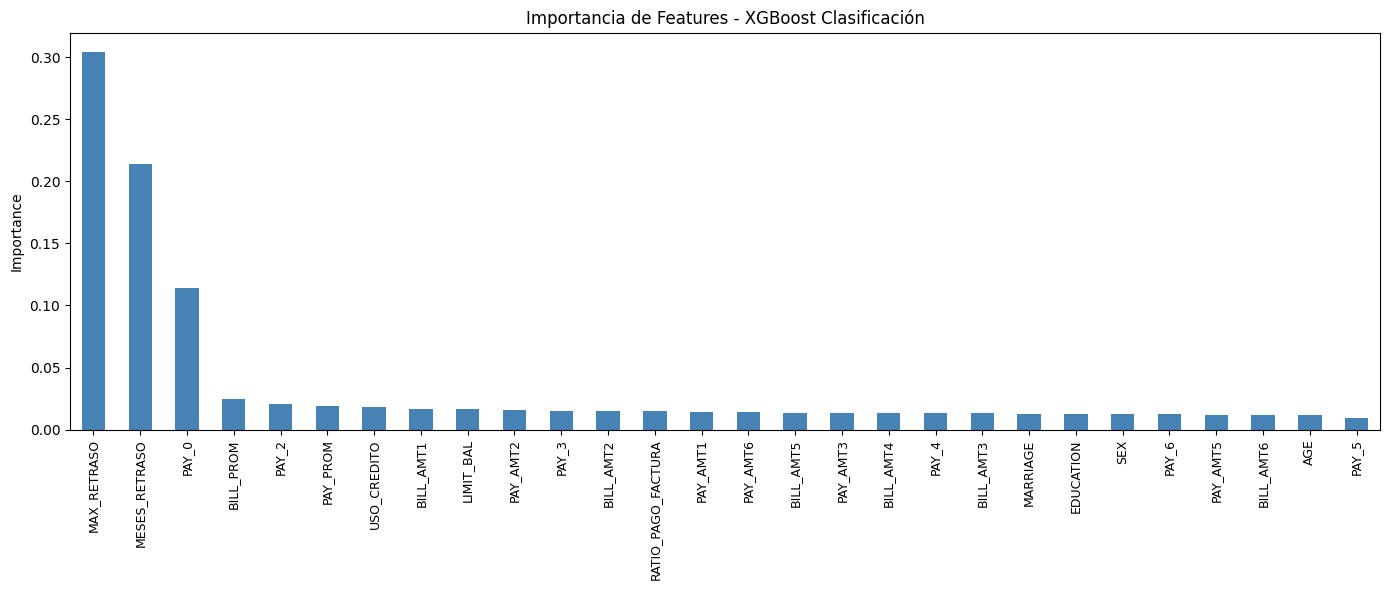

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, classification_report, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

# MODELO 1: Regresión Logística 
lr_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42))
])

lr_clf.fit(X_train, y_train)
y_pred_lr  = lr_clf.predict(X_test)
y_prob_lr  = lr_clf.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
gini_lr = 2 * auc_lr - 1

print("── Regresión Logística ──")
print(f"Accuracy: {acc_lr:.4f}")
print(f"ROC-AUC:  {auc_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"GINI:     {gini_lr:.4f}")

# MODELO 2: XGBoost 
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale,
    random_state=42,
    verbosity=0,
    eval_metric="auc"
)

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

xgb_clf.fit(X_train_imp, y_train)
y_pred_xgb = xgb_clf.predict(X_test_imp)
y_prob_xgb = xgb_clf.predict_proba(X_test_imp)[:, 1]

acc_xgb  = accuracy_score(y_test, y_pred_xgb)
auc_xgb  = roc_auc_score(y_test, y_prob_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
gini_xgb = 2 * auc_xgb - 1

print("\n── XGBoost ──")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"ROC-AUC:  {auc_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"GINI:     {gini_xgb:.4f}")

# Tabla comparativa 
import pandas as pd
results_b = pd.DataFrame({
    "Modelo":   ["Regresión Logística", "XGBoost"],
    "Accuracy": [acc_lr,  acc_xgb],
    "ROC-AUC":  [auc_lr,  auc_xgb],
    "F1-Score": [f1_lr,   f1_xgb],
    "GINI":     [gini_lr, gini_xgb]
})
print("\nComparación de modelos:")
print(results_b)

#  Feature importance XGBoost 
feat_imp_b = pd.Series(xgb_clf.feature_importances_, index=features_b).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
feat_imp_b.plot(kind="bar", color="steelblue")
plt.title("Importancia de Features - XGBoost Clasificación")
plt.ylabel("Importance")
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.show()

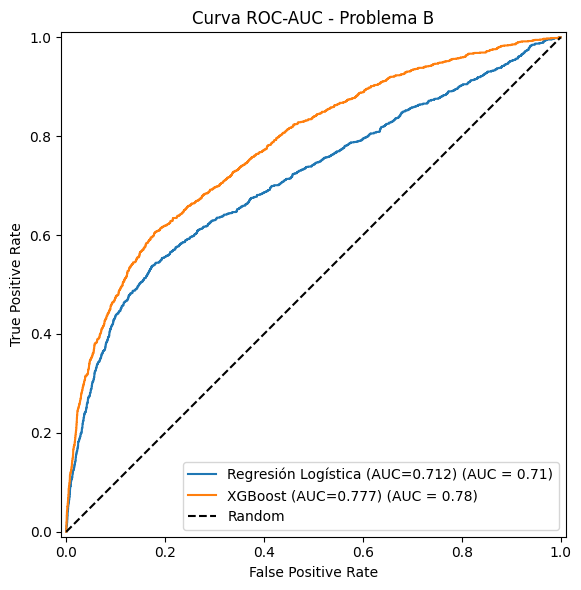

In [10]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name=f"Regresión Logística (AUC={auc_lr:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name=f"XGBoost (AUC={auc_xgb:.3f})", ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("Curva ROC-AUC - Problema B")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Selección del Mejor Modelo

 **XGBoost**  el mejor modelo para predecir `default.payment.next.month` por las siguientes razones:

- **Mayor ROC-AUC**: 0.777 vs 0.711 de la Regresión Logística. En un problema de riesgo crediticio esta es la métrica más importante, ya que mide la capacidad del modelo de distinguir entre clientes que pagarán y los que no, independientemente del umbral de decisión.

- **Mayor GINI**: 0.555 vs 0.423, lo que indica mejor poder discriminativo. En la industria financiera un GINI mayor a 0.40 se considera aceptable y mayor a 0.50 se considera bueno.

- **Mayor F1-Score**: 0.535 vs 0.493, importante dado el desbalance de clases (77.9% vs 22.1%), un F1 más alto indica que el modelo balancea mejor la precisión y el recall para la clase minoritaria (default).

- **Captura relaciones no lineales**: El comportamiento de pago de un cliente es inherentemente no lineal. XGBoost captura estas interacciones de forma natural mientras que la Regresión Logística asume relaciones lineales.

- **Feature engineering validado**: Las variables creadas `MAX_RETRASO` y `MESES_RETRASO`
  resultaron ser las más importantes del modelo (~0.30 y ~0.21), lo que confirma que  el historial de retrasos es el mejor predictor de default.